In [1]:
!pip install -U scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.tree import export_graphviz
from IPython.display import Image
import csv
import pydotplus
from math import sqrt
from scipy.stats import wilcoxon

In [3]:
filepath = 'C:/Users/Lenovo/Documents/HANI/AKADEMIK/CODING SKRIPSI/Dataset/' # <-- sesuaikan path

# Load data
X      = pd.read_csv(filepath + 'radiomic_brain_cancer.csv').to_numpy()
Y_full = pd.read_csv(filepath + 'dosiomic_brain_cancer.csv')

In [4]:
import os
print(os.listdir(filepath))

['dosiomic_brain_cancer.csv', 'radiomic_brain_cancer.csv', 'Y_pred_testing.csv', 'Y_testing.csv']


In [5]:
# Load data
X = pd.read_csv(filepath+'radiomic_brain_cancer.csv').to_numpy()
Y = pd.read_csv(filepath+'dosiomic_brain_cancer.csv')

# -----------------------------------------------------------------------
# Seleksi 19 target dosiomik
# -----------------------------------------------------------------------
TARGET_COLUMNS = [
    # PTV
    'PTV_D2% (GY)', 'PTV_D50% (GY)', 'PTV_D98% (GY)',
    'PTV_V95 (cc)', 'PTV_Volume (cc)',
    # Eye RT & LT
    'Eye RT_Mean dose (GY)', 'Eye RT_Max dose (GY)',
    'Eye LT_Mean dose (GY)', 'Eye LT_Max dose (GY)',
    # Optic Nerve RT & LT
    'Optic Nerve RT_Mean dose (GY)', 'Optic Nerve RT_Max dose (GY)',
    'Optic Nerve LT_Mean dose (GY)', 'Optic Nerve LT_Max dose (GY)',
    # Lens RT & LT
    'Lens RT_Mean dose (GY)', 'Lens RT_Max dose (GY)',
    'Lens LT_Mean dose (GY)', 'Lens LT_Max dose (GY)',
    # Brainstem
    'Brainstem_Mean dose (GY)', 'Brainstem_Max dose (GY)'
]

# Terapkan target selection (Ubah Y_full menjadi Y di sini)
Y_df = Y[TARGET_COLUMNS]
Y_label = TARGET_COLUMNS
Y = Y_df.to_numpy()

print(f"Shape X: {X.shape}")
print(f"Shape Y: {Y.shape} (19 Target Terpilih)")

Shape X: (178, 112)
Shape Y: (178, 19) (19 Target Terpilih)


In [6]:
# Split data into training and testing sets
X_training, X_testing, Y_training, Y_testing = train_test_split(X, Y, test_size=0.3, random_state=0)
print(X_training.shape, X_testing.shape)

(124, 112) (54, 112)


In [7]:
# Define model
regressor = RandomForestRegressor(random_state=0)

In [8]:
# Parameter grid for grid search
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_features': [12, 14, 15],
    'min_samples_split': [5, 6, 8],
    'max_depth' : [10, 14, 17]
}

In [9]:
grid_search = GridSearchCV(estimator=regressor, param_grid=param_grid, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1, error_score='raise')

In [10]:
kf = KFold(n_splits=5)

In [11]:
kf = KFold(n_splits=5)
prediction = []
mse_set = []
for train_index, test_index in kf.split(X_training):
  print(train_index, test_index)
  X_train, X_test = X_training[train_index], X_training[test_index]
  Y_train, Y_test = Y_training[train_index], Y_training[test_index]
  grid_search.fit(X_training, Y_training)
  Y_pred = grid_search.predict(X_test)
  mse_set.append(mean_squared_error(Y_test, Y_pred))
  for i in range(len(Y_pred[:,0])):
    prediction.append(Y_pred[i,:].tolist())

[ 25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42
  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121 122 123] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121 122 123] [25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42

In [12]:
# Menampilkan hasil grid search
print("Best parameters: ", grid_search.best_params_)
print("Best score: ", sqrt(np.abs(grid_search.best_score_)))

Best parameters:  {'max_depth': 17, 'max_features': 12, 'min_samples_split': 5, 'n_estimators': 300}
Best score:  0.21665000898083484


In [13]:
mse_set

[0.012321812960701225,
 0.011180570566626576,
 0.012801802425520231,
 0.014286522041167897,
 0.013270346079193748]

In [14]:
prediction = np.array(prediction)

In [15]:
mse_training = []
std_deviation = []
for i in range(len(Y_label)):
  mse_training.append(mean_squared_error(Y_training[:,i], prediction[:,i]))

  print(f'{i} {Y_label[i]}: {mse_training[i]:.5f}')

0 PTV_D2% (GY): 0.01352
1 PTV_D50% (GY): 0.01349
2 PTV_D98% (GY): 0.01965
3 PTV_V95 (cc): 0.00319
4 PTV_Volume (cc): 0.00000
5 Eye RT_Mean dose (GY): 0.00339
6 Eye RT_Max dose (GY): 0.01651
7 Eye LT_Mean dose (GY): 0.00336
8 Eye LT_Max dose (GY): 0.01843
9 Optic Nerve RT_Mean dose (GY): 0.01893
10 Optic Nerve RT_Max dose (GY): 0.02864
11 Optic Nerve LT_Mean dose (GY): 0.01651
12 Optic Nerve LT_Max dose (GY): 0.02796
13 Lens RT_Mean dose (GY): 0.00087
14 Lens RT_Max dose (GY): 0.00131
15 Lens LT_Mean dose (GY): 0.00078
16 Lens LT_Max dose (GY): 0.00131
17 Brainstem_Mean dose (GY): 0.02566
18 Brainstem_Max dose (GY): 0.02908


In [16]:
Y_pred_training = grid_search.predict(X_training)
mean_squared_error(Y_training, Y_pred_training)

0.012768193594766518

In [17]:
testing = grid_search.predict(X_testing)

In [18]:
Y_pred_testing = grid_search.predict(X_testing)
mean_squared_error(Y_testing, Y_pred_testing)

0.0493385225843933

In [19]:
from sklearn.metrics import mean_absolute_error

mse_testing, mae_testing = [], []

for i in range(len(Y_label)):
    mse_testing.append(mean_squared_error(Y_testing[:, i], Y_pred_testing[:, i]))
    mae_testing.append(mean_absolute_error(Y_testing[:, i], Y_pred_testing[:, i]))

print('=' * 80)
print('MSE & MAE PER FITUR DOSIOMIC  (Testing Set)')
print('=' * 80)
print(f'{"No":<5} {"Feature":<40} {"MSE":>12} {"MAE":>12}')
print('-' * 72)
for i, label in enumerate(Y_label):
    print(f'{i+1:<5} {label:<40} {mse_testing[i]:>12.6f} {mae_testing[i]:>12.6f}')
print('-' * 72)
print(f'{"Overall":<46} {np.mean(mse_testing):>12.6f} {np.mean(mae_testing):>12.6f}')
print('=' * 80)

MSE & MAE PER FITUR DOSIOMIC  (Testing Set)
No    Feature                                           MSE          MAE
------------------------------------------------------------------------
1     PTV_D2% (GY)                                 0.064702     0.141691
2     PTV_D50% (GY)                                0.056628     0.133986
3     PTV_D98% (GY)                                0.061827     0.158079
4     PTV_V95 (cc)                                 0.016831     0.027008
5     PTV_Volume (cc)                              0.000000     0.000000
6     Eye RT_Mean dose (GY)                        0.007361     0.065528
7     Eye RT_Max dose (GY)                         0.049115     0.172775
8     Eye LT_Mean dose (GY)                        0.008355     0.068070
9     Eye LT_Max dose (GY)                         0.048690     0.188281
10    Optic Nerve RT_Mean dose (GY)                0.076188     0.236500
11    Optic Nerve RT_Max dose (GY)                 0.120470     0.302034
12    O

In [20]:
# Menyimpan hasil prediksi testing ke file CSV di Google Drive
result_df = pd.DataFrame(Y_pred_testing, columns=Y_label).to_csv(filepath + 'Y_pred_testing.csv', index=False)

# Menyimpan data testing ke file CSV di Google Drive
result_df = pd.DataFrame(Y_testing, columns=Y_label).to_csv(filepath + 'Y_testing.csv', index=False)

# Tentukan path untuk menyimpan file CSV
output_filepath = '/content/drive/MyDrive/Data_Pasien/prediction_resultsFIX.csv'


print("Hasil prediksi dan label sebenarnya telah disimpan ke dalam file CSV.")

Hasil prediksi dan label sebenarnya telah disimpan ke dalam file CSV.


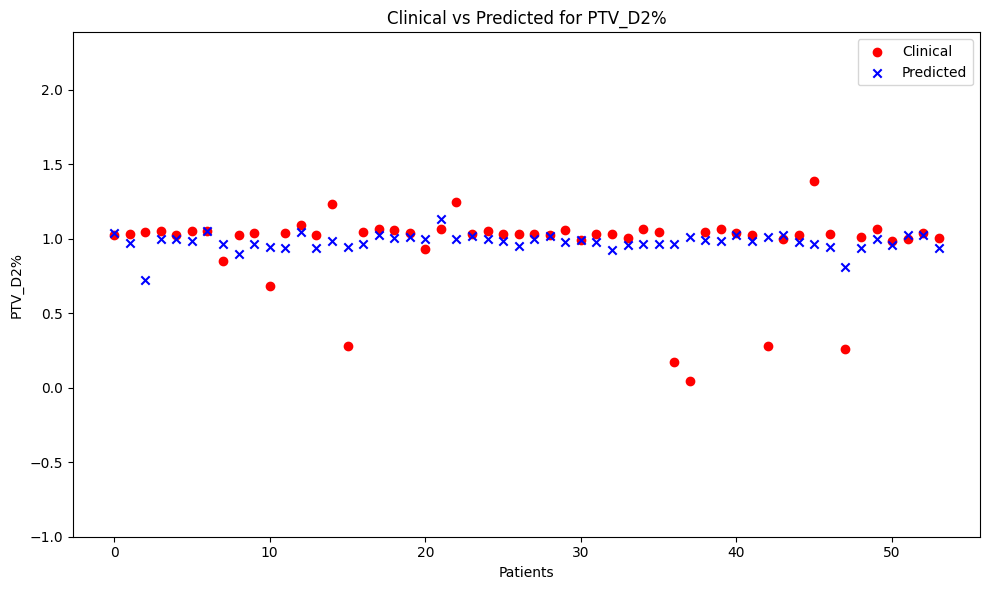

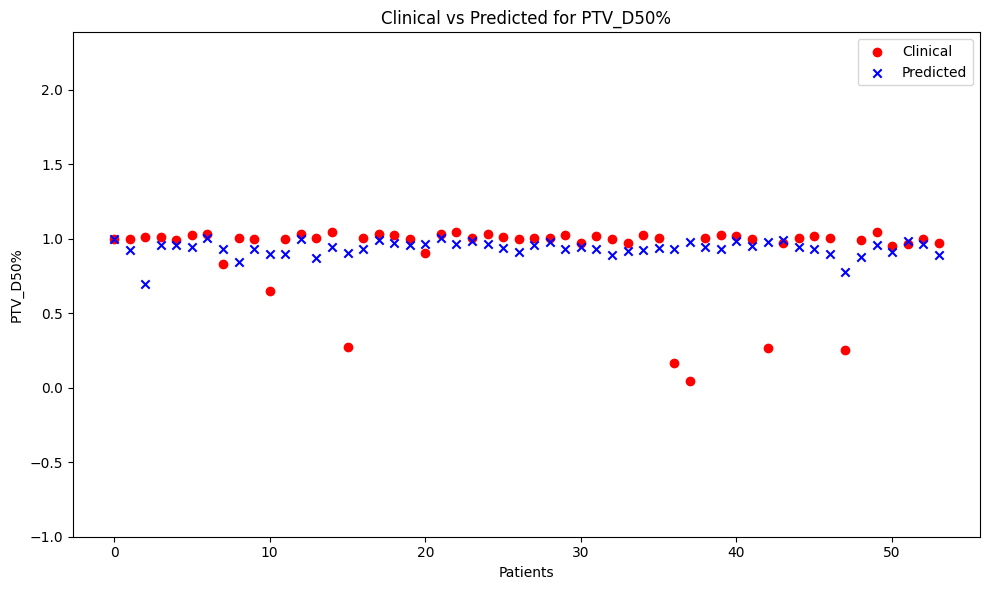

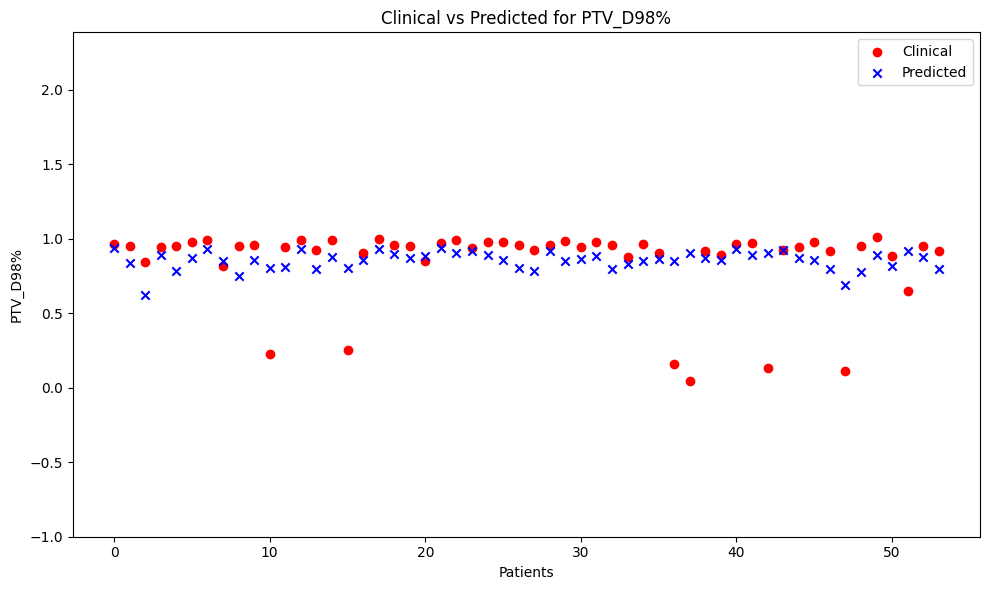

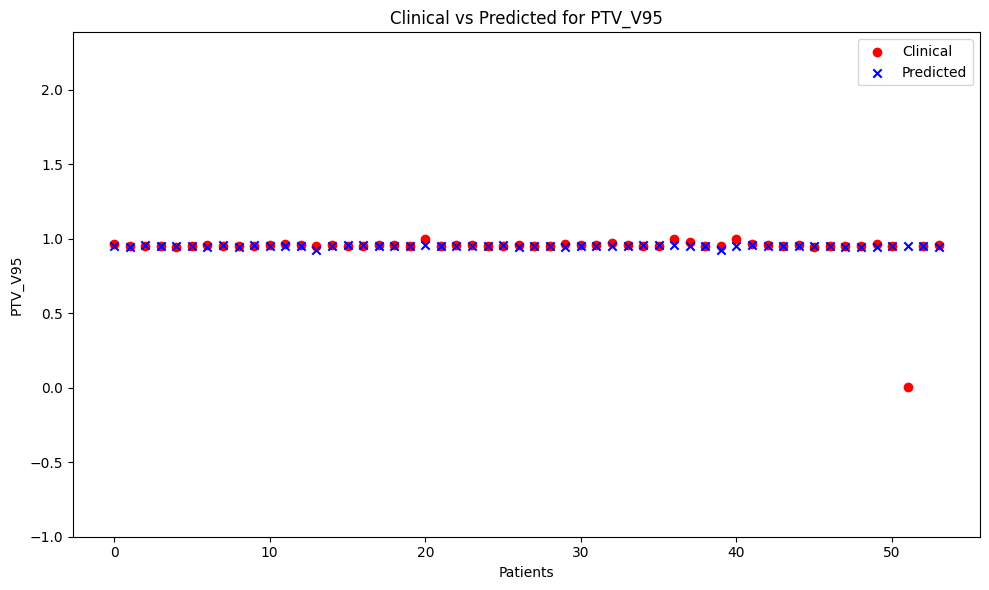

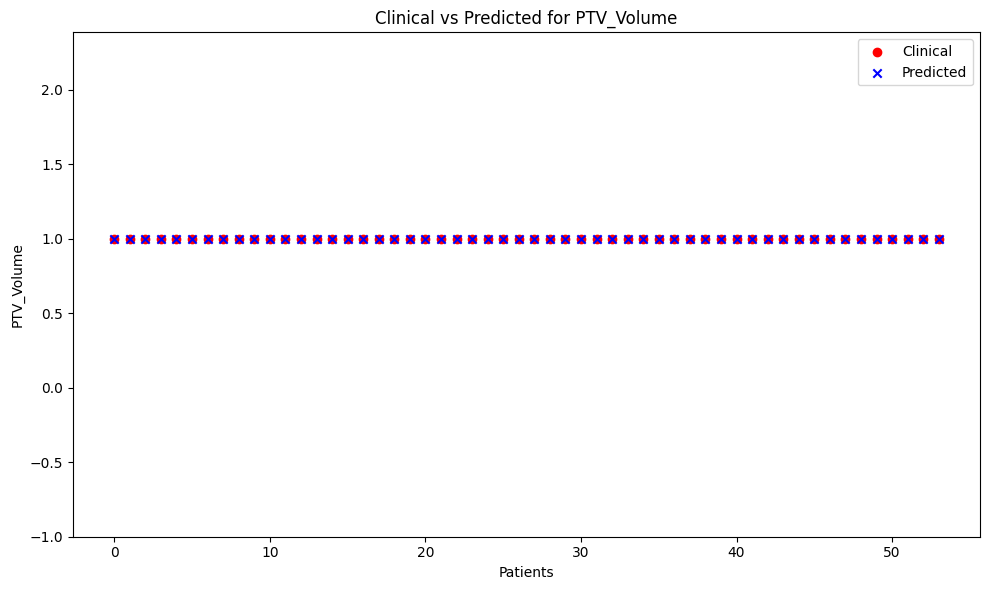

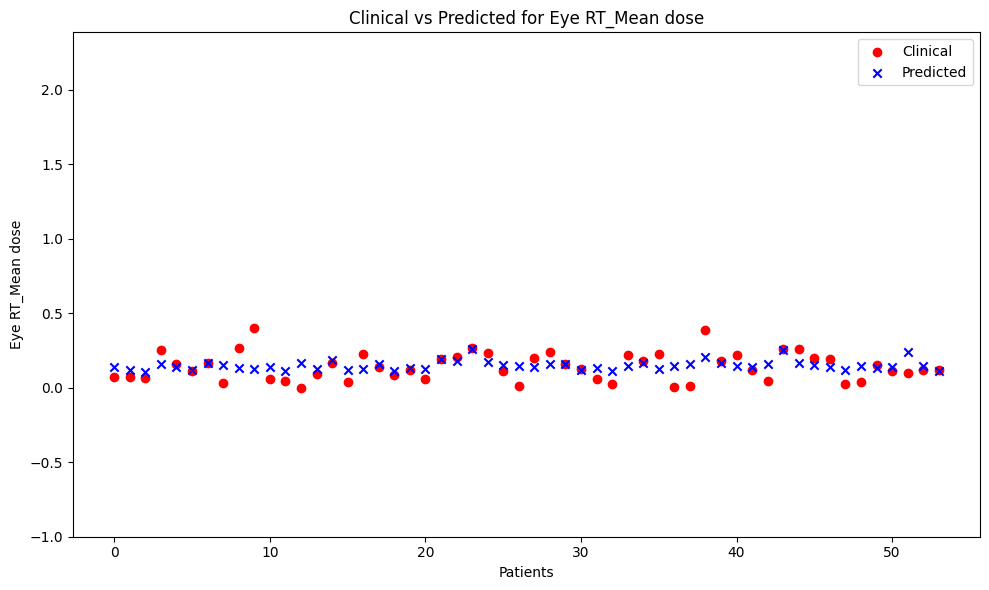

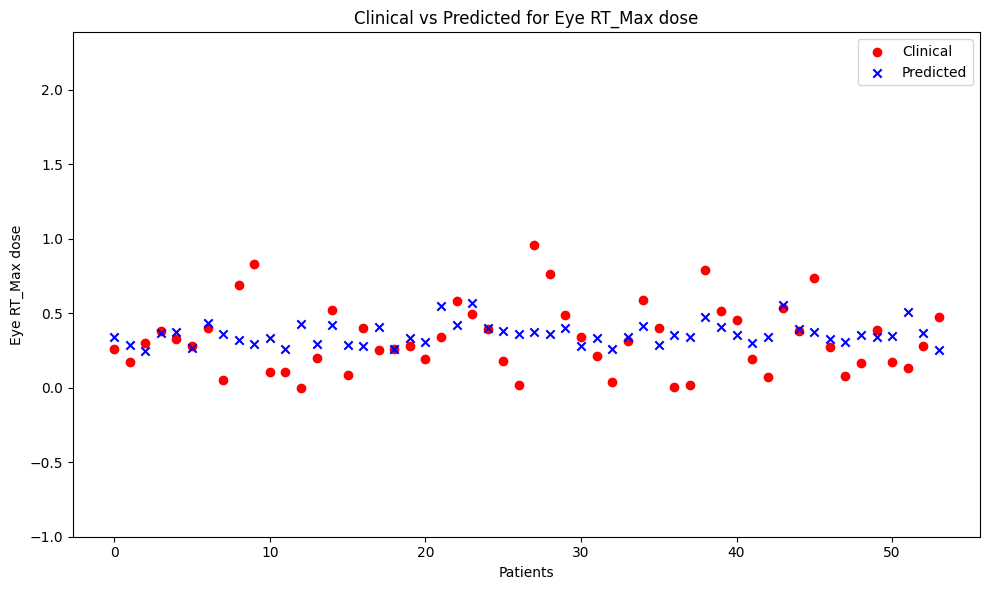

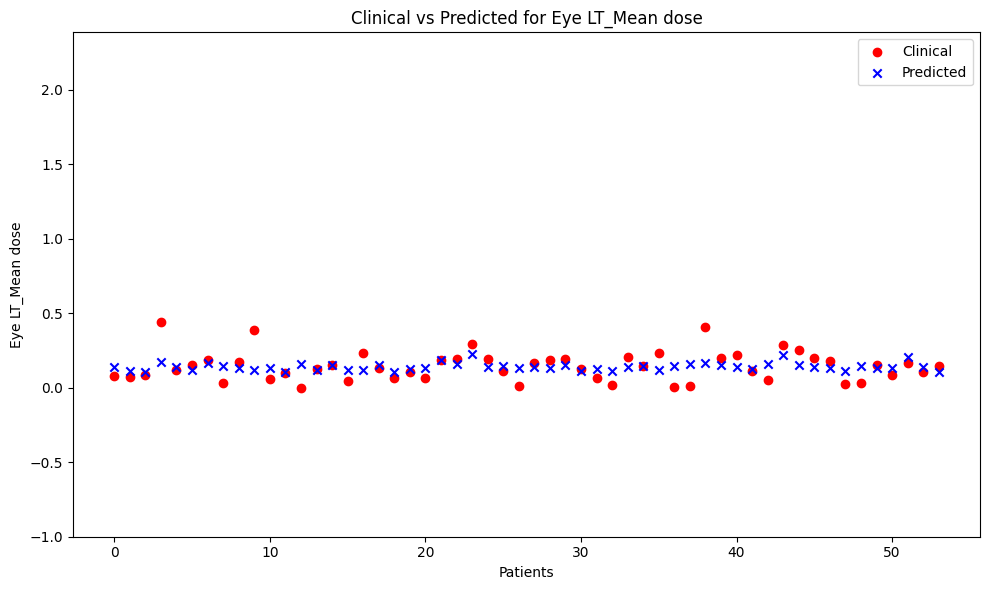

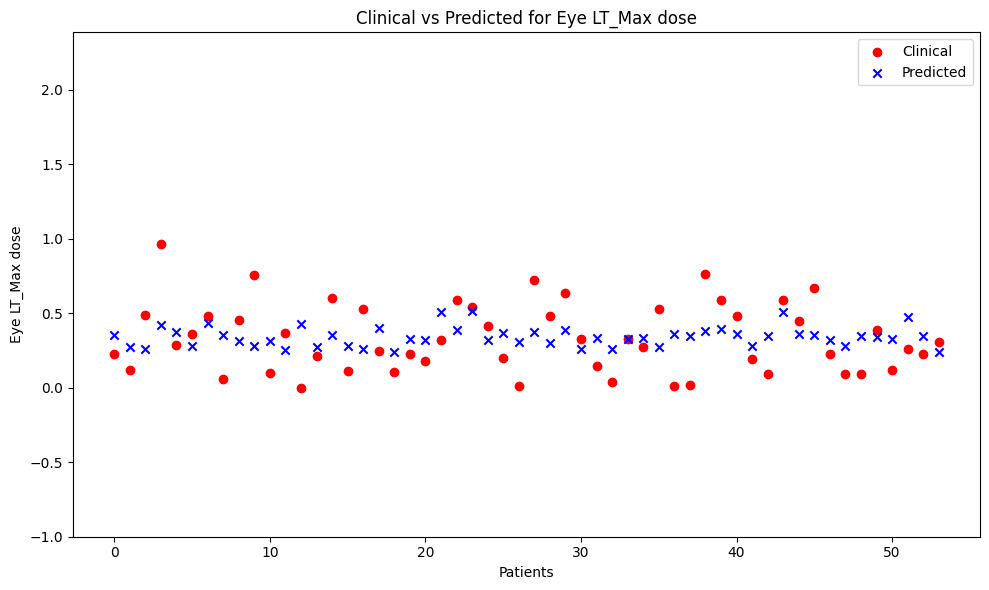

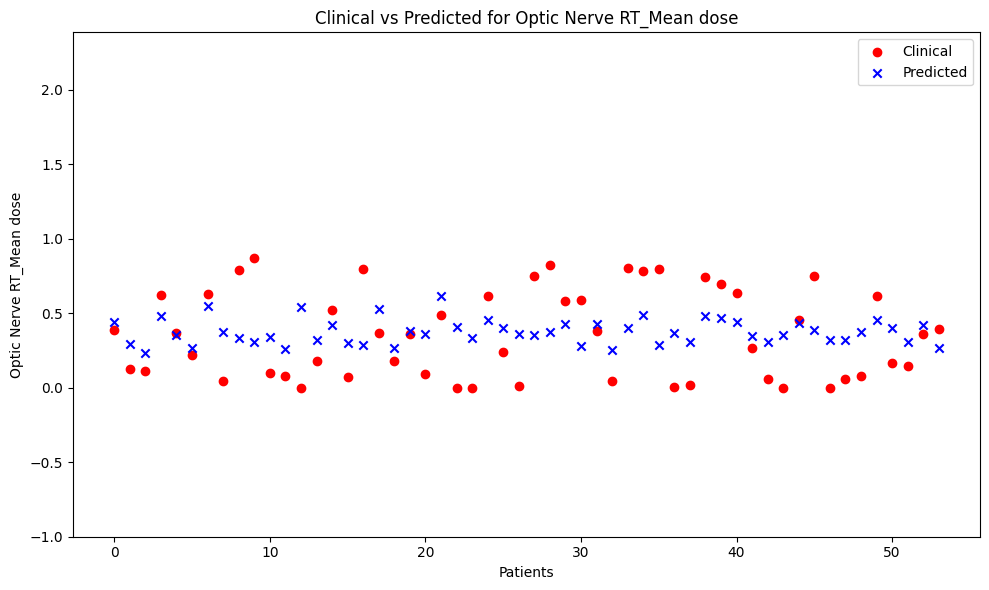

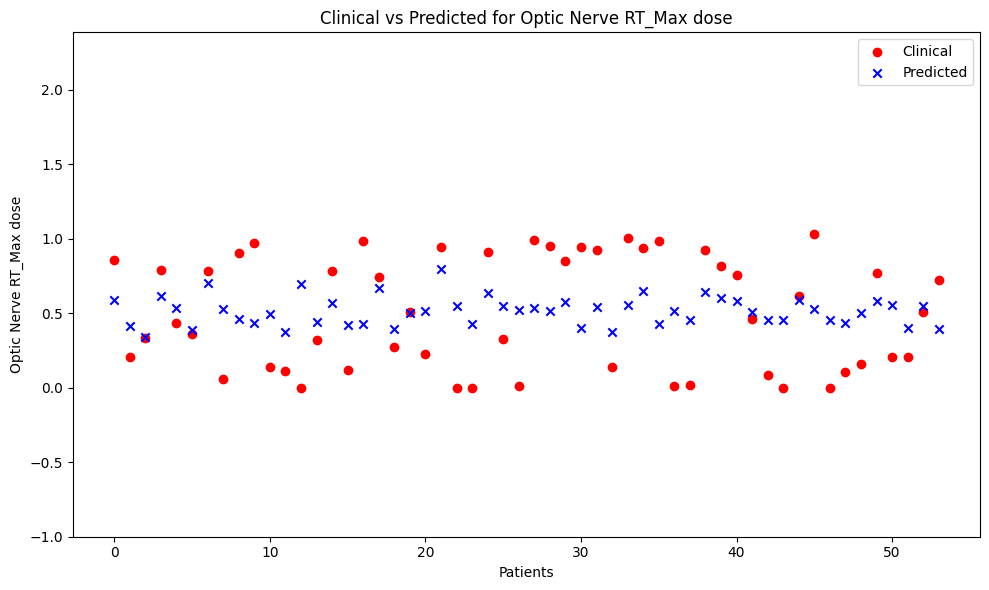

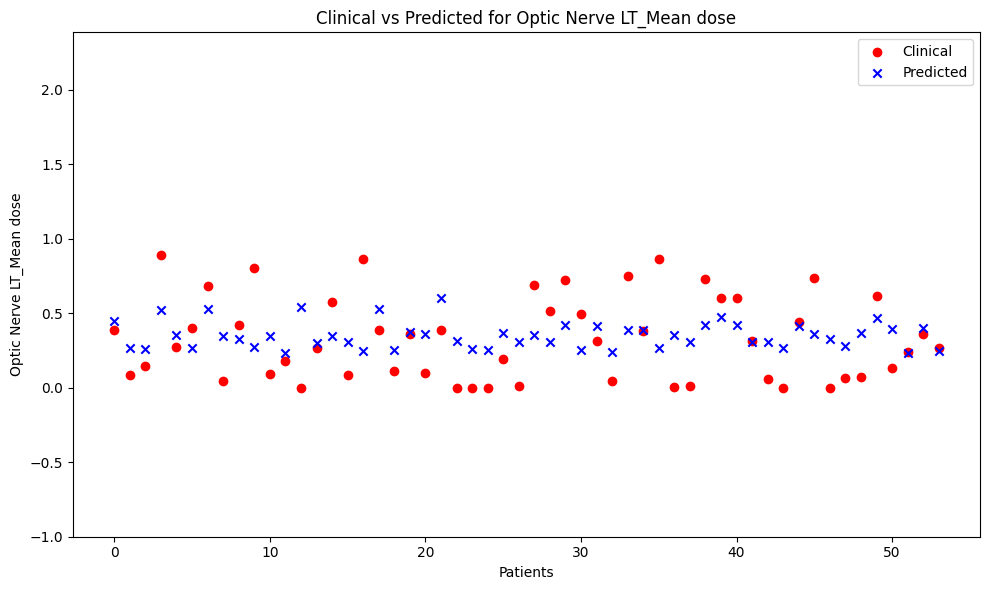

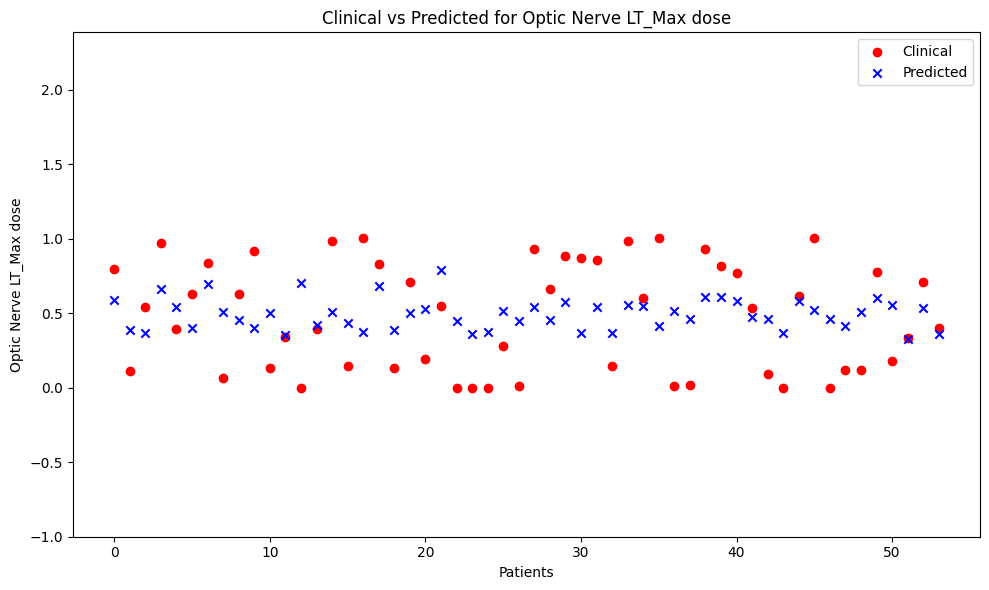

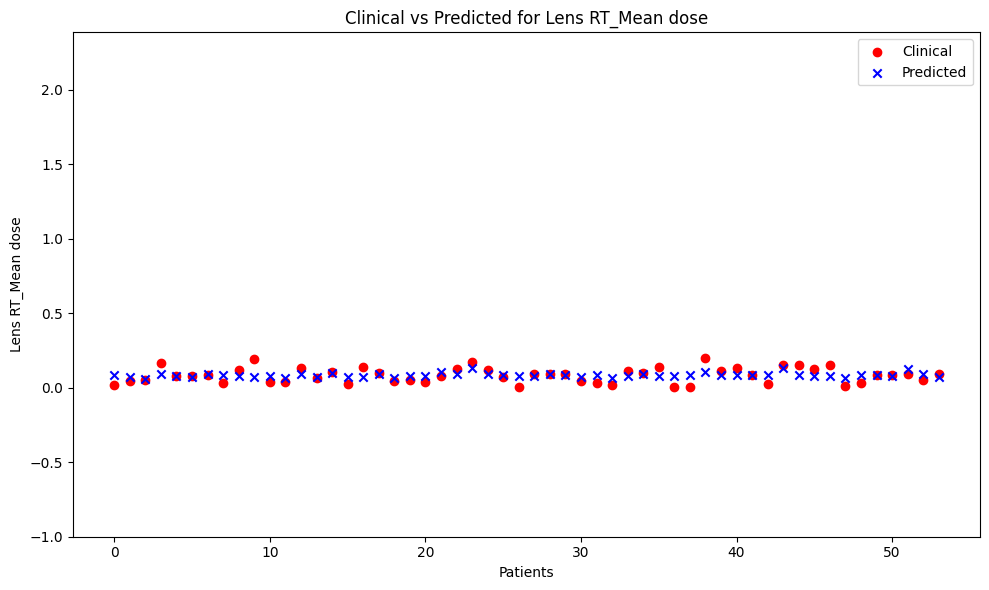

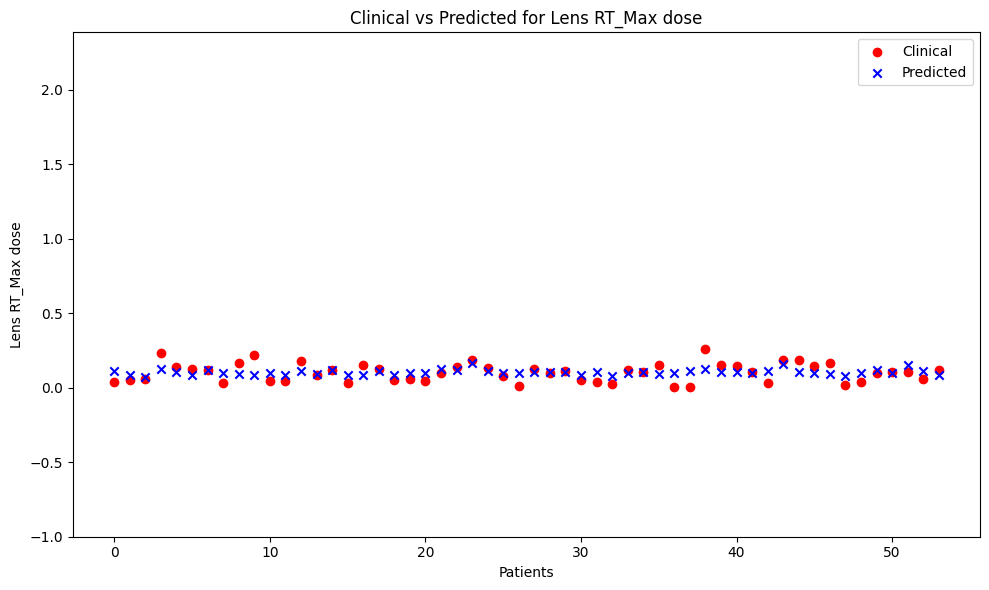

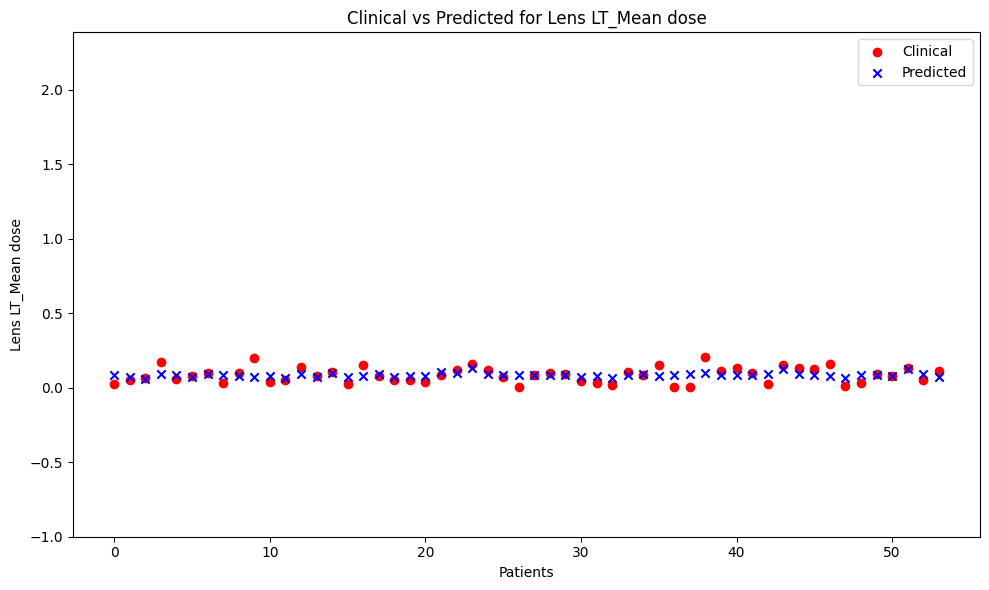

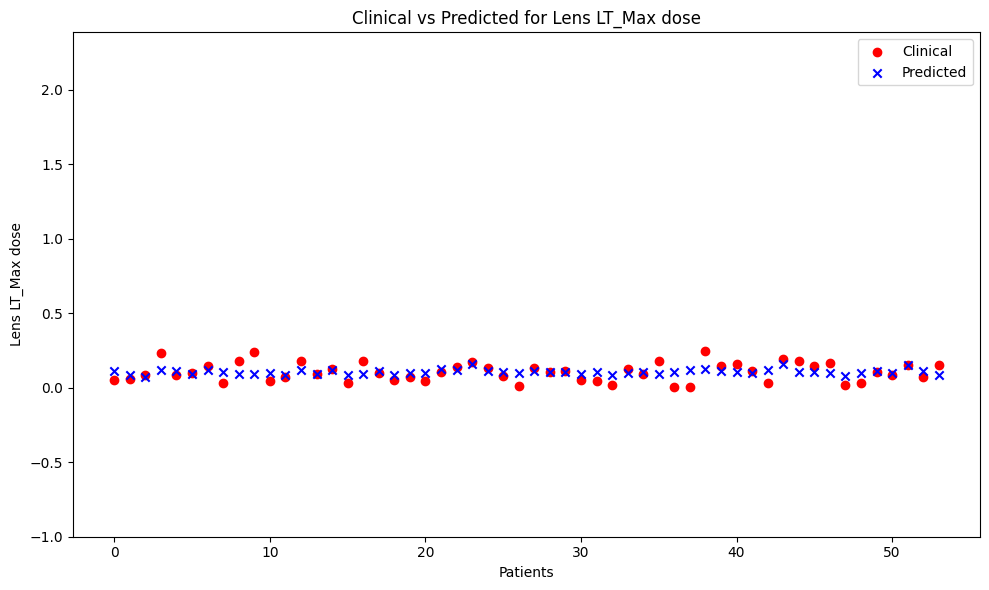

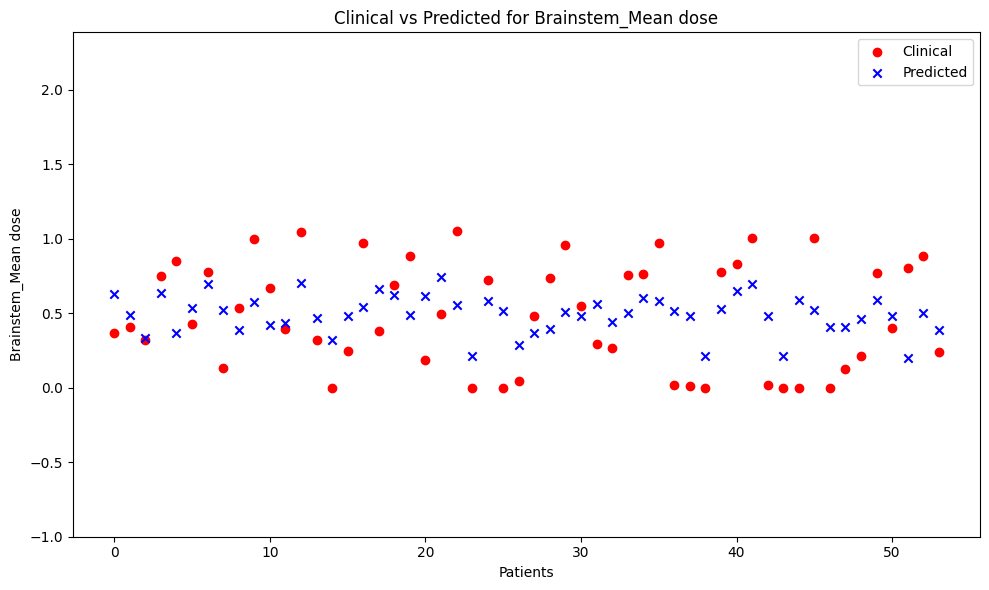

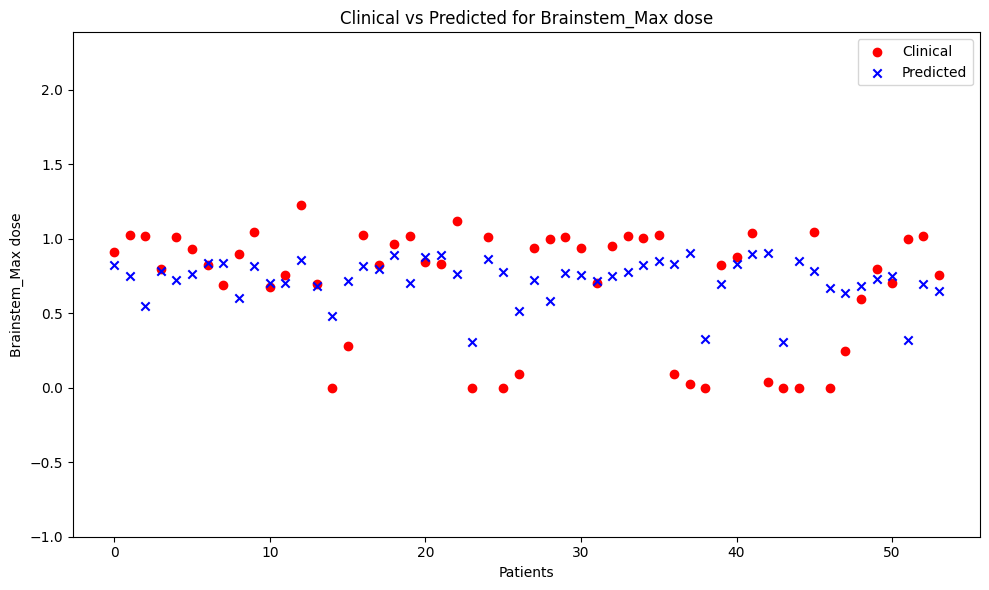

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Asumsikan Y_testing, Y_pred_testing, dan Y_label sudah didefinisikan
# Y_testing: array dari nilai sebenarnya untuk data testing
# Y_pred_testing: array prediksi yang dihasilkan dari model untuk data testing
# Y_label: list label untuk setiap kolom di Y_testing, sesuai dengan data Anda

# Fungsi untuk menghapus penanda dari nama fitur
def remove_suffix(name):
    if " (GY)" in name:
        name = name.replace(" (GY)", "")
    if " (cc)" in name:
        name = name.replace(" (cc)", "")
    return name

# Tentukan batas minimum dan maksimum untuk seluruh data
y_min = min(Y_testing.min(), Y_pred_testing.min()) - 1
y_max = max(Y_testing.max(), Y_pred_testing.max()) + 1

# Mengiterasi melalui setiap kolom dalam Y_label
for column in Y_label:
    plt.figure(figsize=(10, 6))  # Mengatur ukuran gambar
    column_index = Y_label.index(column)
    plt.scatter(range(len(Y_testing[:, column_index])), Y_testing[:, column_index], marker='o', color='red', label='Clinical')
    plt.scatter(range(len(Y_testing[:, column_index])), Y_pred_testing[:, column_index], marker='x', color='blue', label='Predicted')
    plt.title(f'Clinical vs Predicted for {remove_suffix(column)}')
    plt.xlabel('Patients')
    plt.ylabel(remove_suffix(column))
    plt.legend()
    plt.ylim(y_min, y_max)  # Mengatur batas sumbu y
    plt.tight_layout()
    plt.show()

In [22]:
# Define function to calculate HI and CI
def calculate_hi_ci(df, indices):
    hi_list = []
    ci_list = []

    ptv_d2 = df[:, indices['PTV_D2% (GY)']]
    ptv_d50 = df[:, indices['PTV_D50% (GY)']]
    ptv_d98 = df[:, indices['PTV_D98% (GY)']]
    ptv_v95 = df[:, indices['PTV_V95 (cc)']]
    ptv_volume = df[:, indices['PTV_Volume (cc)']]

    for i in range(len(ptv_d2)):
        hi = (ptv_d2[i] - ptv_d98[i]) / ptv_d50[i]
        ci = ptv_v95[i] / ptv_volume[i]
        hi_list.append(hi)
        ci_list.append(ci)

    return hi_list, ci_list

# Define the indices for the columns of interest
indices = {label: i for i, label in enumerate(Y_label)}

# Calculate true HI and CI
hi_true, ci_true = calculate_hi_ci(Y_testing, indices)

# Calculate predicted HI and CI
hi_pred, ci_pred = calculate_hi_ci(Y_pred_testing, indices)

# Create DataFrames for true and predicted HI and CI
hi_ci_true_df = pd.DataFrame({
    'HI_true': hi_true,
    'CI_true': ci_true
})

hi_ci_pred_df = pd.DataFrame({
    'HI_pred': hi_pred,
    'CI_pred': ci_pred
})

# Concatenate the true and predicted HI and CI DataFrames
combined_hi_ci_df = pd.concat([hi_ci_true_df, hi_ci_pred_df], axis=1)

# Print the DataFrame to verify
print(combined_hi_ci_df)

# Simpan HI_true dan CI_true dalam satu file
#hi_ci_true_df.to_csv('/content/drive/My Drive/Data_Pasien/hi_ci_clinical.csv', index=False)

# Simpan HI_pred dan CI_pred dalam satu file terpisah
#hi_ci_pred_df.to_csv('/content/drive/My Drive/Data_Pasien/hi_ci_predicted.csv', index=False)

print("Data HI_true dan CI_true telah disimpan dalam satu file.")
print("Data HI_pred dan CI_pred telah disimpan dalam file terpisah.")

     HI_true   CI_true   HI_pred   CI_pred
0   0.058324  0.961273  0.103488  0.953775
1   0.079483  0.952788  0.141312  0.944705
2   0.193477  0.952323  0.148316  0.955418
3   0.108247  0.948454  0.112237  0.950451
4   0.070394  0.946108  0.227131  0.953908
5   0.070196  0.949920  0.121799  0.953306
6   0.060178  0.955278  0.120736  0.943044
7   0.043132  0.949645  0.123444  0.955213
8   0.074427  0.949518  0.174444  0.945523
9   0.075851  0.948929  0.116577  0.956447
10  0.699187  0.954522  0.158993  0.954199
11  0.096597  0.963864  0.139105  0.948108
12  0.093445  0.955438  0.111971  0.953125
13  0.104400  0.949986  0.164397  0.924378
14  0.230822  0.959316  0.110746  0.949373
15  0.104080  0.951926  0.154780  0.955305
16  0.140289  0.951906  0.115139  0.956589
17  0.067670  0.959178  0.100732  0.950603
18  0.094721  0.954697  0.109858  0.954059
19  0.091392  0.949787  0.143855  0.950614
20  0.091008  1.000000  0.115351  0.956412
21  0.095757  0.954272  0.197907  0.949613
22  0.24532

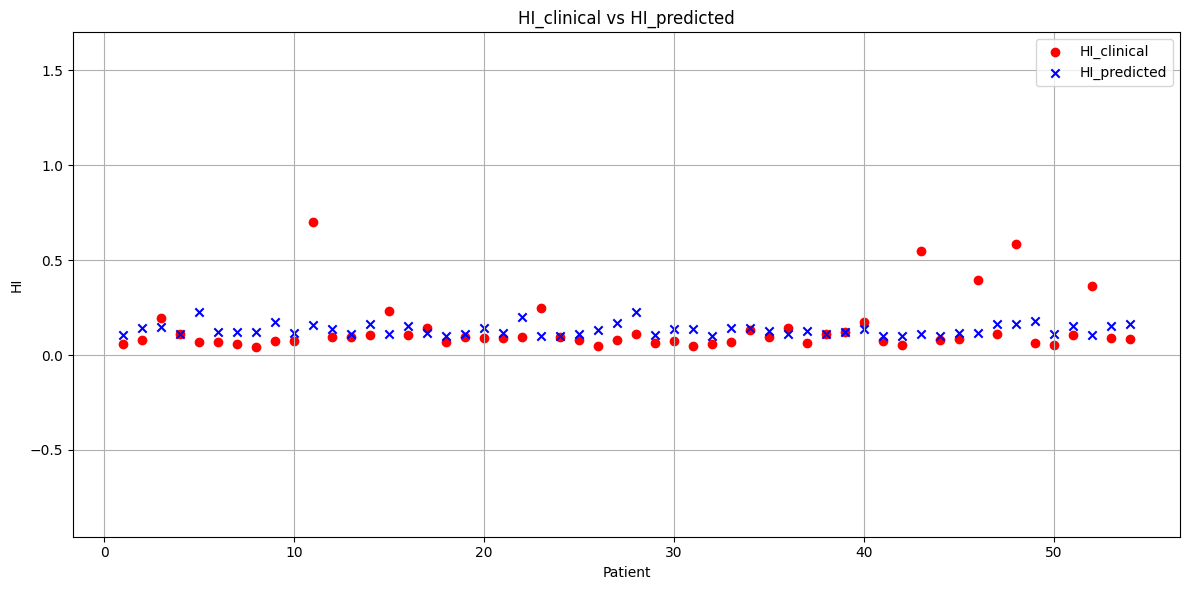

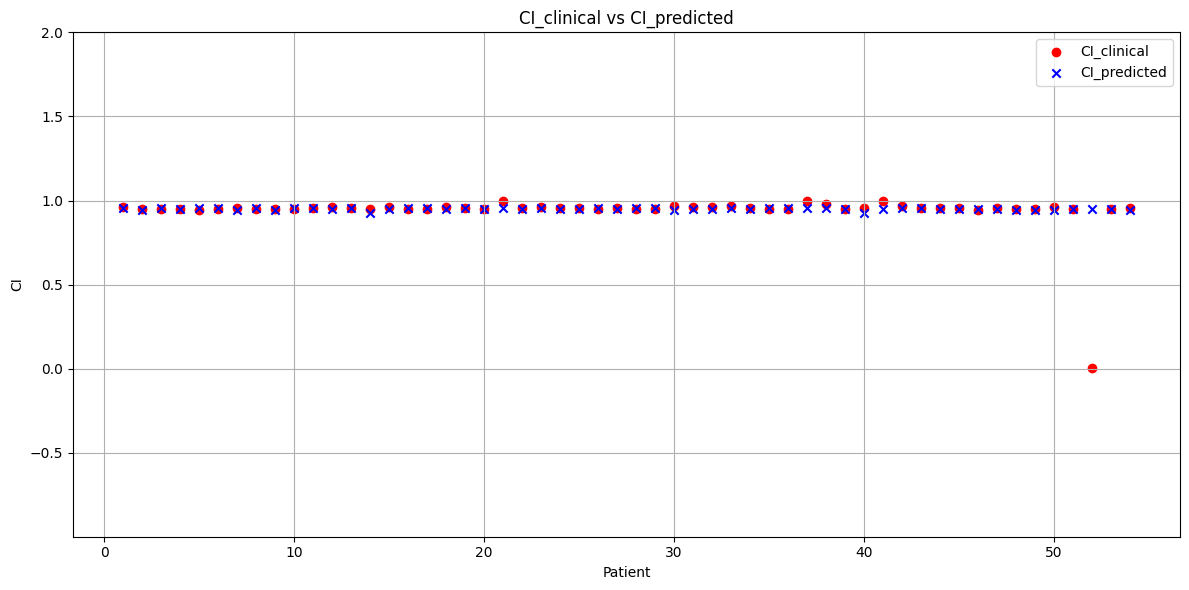

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data HI_true dan HI_pred dari file CSV
#hi_ci_true_df = pd.read_csv('/content/drive/My Drive/Data_Pasien/hi_ci_clinical.csv')
#hi_ci_pred_df = pd.read_csv('/content/drive/My Drive/Data_Pasien/hi_ci_predicted.csv')

# Ambil jumlah pasien sebagai sumbu x
Patient = range(1, len(hi_ci_true_df) + 1)

# Tentukan batas minimum dan maksimum untuk HI
hi_min = min(hi_ci_true_df['HI_true'].min(), hi_ci_pred_df['HI_pred'].min()) - 1
hi_max = max(hi_ci_true_df['HI_true'].max(), hi_ci_pred_df['HI_pred'].max()) + 1

# Tentukan batas minimum dan maksimum untuk CI
ci_min = min(hi_ci_true_df['CI_true'].min(), hi_ci_pred_df['CI_pred'].min()) - 1
ci_max = max(hi_ci_true_df['CI_true'].max(), hi_ci_pred_df['CI_pred'].max()) + 1

# Plot HI_true dan HI_pred
plt.figure(figsize=(12, 6))

# Plot HI_true dengan marker 'o' dan warna merah
plt.scatter(Patient, hi_ci_true_df['HI_true'], color='red', marker='o', label='HI_clinical')

# Plot HI_pred dengan marker 'x' dan warna biru
plt.scatter(Patient, hi_ci_pred_df['HI_pred'], color='blue', marker='x', label='HI_predicted')

plt.xlabel('Patient')
plt.ylabel('HI')
plt.title('HI_clinical vs HI_predicted')
plt.legend()
plt.grid(True)
plt.ylim(hi_min, hi_max)  # Mengatur batas sumbu y
plt.tight_layout()
plt.show()

# Plot CI_true dan CI_pred
plt.figure(figsize=(12, 6))

# Plot CI_true dengan marker 'o' dan warna merah
plt.scatter(Patient, hi_ci_true_df['CI_true'], color='red', marker='o', label='CI_clinical')

# Plot CI_pred dengan marker 'x' dan warna biru
plt.scatter(Patient, hi_ci_pred_df['CI_pred'], color='blue', marker='x', label='CI_predicted')

plt.xlabel('Patient')
plt.ylabel('CI')
plt.title('CI_clinical vs CI_predicted')
plt.legend()
plt.grid(True)
plt.ylim(ci_min, ci_max)  # Mengatur batas sumbu y
plt.tight_layout()
plt.show()


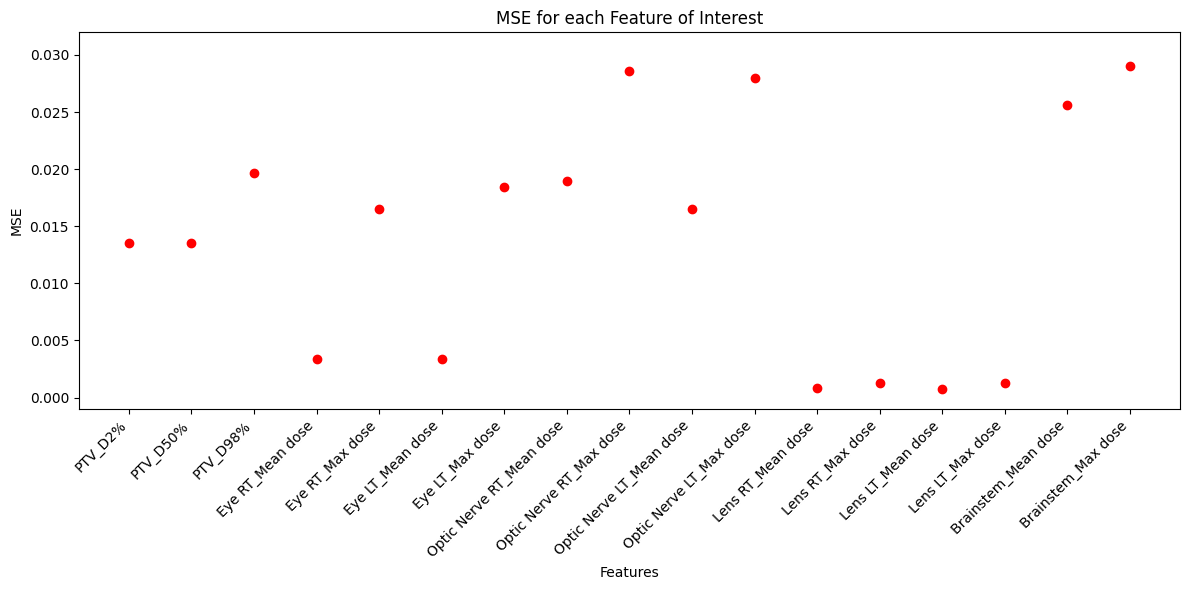

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Define the columns of interest
columns_of_interest = [
    "PTV_D2%", "PTV_D50%", "PTV_D98%",
    "Eye RT_Mean dose", "Eye RT_Max dose",
    "Eye LT_Mean dose", "Eye LT_Max dose",
    "Optic Nerve RT_Mean dose", "Optic Nerve RT_Max dose",
    "Optic Nerve LT_Mean dose", "Optic Nerve LT_Max dose",
    "Lens RT_Mean dose", "Lens RT_Max dose",
    "Lens LT_Mean dose", "Lens LT_Max dose",
    "Brainstem_Mean dose", "Brainstem_Max dose"
]

# Calculate MSE for the columns of interest
mse_training_interest = []
for column in columns_of_interest:
    column_with_gy = column + " (GY)"
    i = Y_label.index(column_with_gy)
    mse = mean_squared_error(Y_training[:, i], prediction[:, i])
    mse_training_interest.append(mse)

# Plot the MSE for each column of interest
plt.figure(figsize=(12, 6))
plt.scatter(range(len(columns_of_interest)), mse_training_interest, color='red')
plt.xlabel('Features')
plt.ylabel('MSE')
plt.title('MSE for each Feature of Interest')
plt.xticks(range(len(columns_of_interest)), columns_of_interest, rotation=45, ha='right')  # Rotate labels

# Set y-axis scale
plt.ylim(-0.001, max(mse_training_interest) * 1.1)  # Adjust the factor as needed

plt.tight_layout()
plt.show()

Patient with smallest overall error: 6
Total Error: 0.7841153508340081

Patient with largest overall error: 37
Total Error: 6.911148172614157



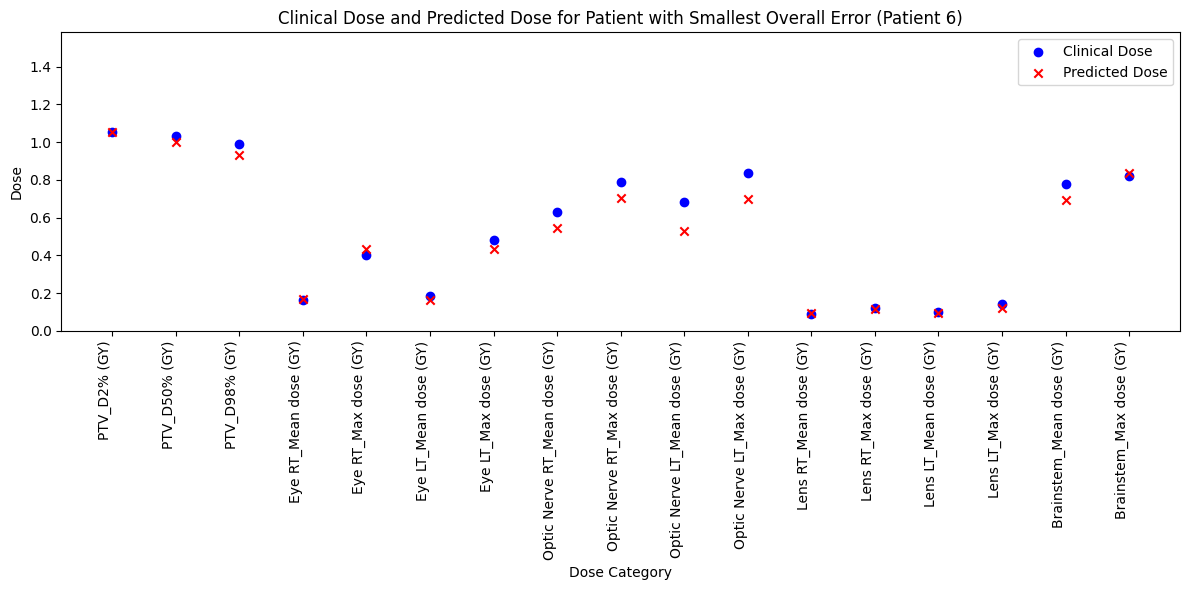

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Kolom yang diinginkan
columns_of_interest = [
    "PTV_D2% (GY)", "PTV_D50% (GY)", "PTV_D98% (GY)",
    "Eye RT_Mean dose (GY)", "Eye RT_Max dose (GY)",
    "Eye LT_Mean dose (GY)", "Eye LT_Max dose (GY)",
    "Optic Nerve RT_Mean dose (GY)", "Optic Nerve RT_Max dose (GY)",
    "Optic Nerve LT_Mean dose (GY)", "Optic Nerve LT_Max dose (GY)",
    "Lens RT_Mean dose (GY)", "Lens RT_Max dose (GY)",
    "Lens LT_Mean dose (GY)", "Lens LT_Max dose (GY)",
    "Brainstem_Mean dose (GY)", "Brainstem_Max dose (GY)"
]

# Mendapatkan indeks kolom yang diinginkan
indices_of_interest = [Y_label.index(col) for col in columns_of_interest]

# Menghitung kesalahan absolut
absolute_errors = np.abs(Y_testing[:, indices_of_interest] - Y_pred_testing[:, indices_of_interest])

# Menghitung kesalahan total untuk setiap pasien
total_errors = np.sum(absolute_errors, axis=1)

# Menemukan pasien dengan kesalahan total terkecil
min_error_patient_index = np.argmin(total_errors)

# Menemukan pasien dengan kesalahan total terbesar
max_error_patient_index = np.argmax(total_errors)

# Menampilkan hasil untuk pasien dengan kesalahan total terkecil
print(f"Patient with smallest overall error: {min_error_patient_index}")
print(f"Total Error: {total_errors[min_error_patient_index]}\n")

# Menampilkan hasil untuk pasien dengan kesalahan total terbesar
print(f"Patient with largest overall error: {max_error_patient_index}")
print(f"Total Error: {total_errors[max_error_patient_index]}\n")

# Mendapatkan dosis klinis dan prediksi untuk pasien dengan kesalahan total terkecil
clinical_dose_min_error = Y_testing[min_error_patient_index, indices_of_interest]
predicted_dose_min_error = Y_pred_testing[min_error_patient_index, indices_of_interest]

# Mendapatkan dosis klinis dan prediksi untuk pasien dengan kesalahan total terbesar
clinical_dose_max_error = Y_testing[max_error_patient_index, indices_of_interest]
predicted_dose_max_error = Y_pred_testing[max_error_patient_index, indices_of_interest]

# Plotting the data for the patient with the smallest overall error
plt.figure(figsize=(12, 6))
plt.scatter(range(len(columns_of_interest)), clinical_dose_min_error, marker='o', color='b', label='Clinical Dose')
plt.scatter(range(len(columns_of_interest)), predicted_dose_min_error, marker='x', color='r', label='Predicted Dose')
plt.xlabel('Dose Category')
plt.ylabel('Dose')
plt.title(f'Clinical Dose and Predicted Dose for Patient with Smallest Overall Error (Patient {min_error_patient_index})')
plt.xticks(range(len(columns_of_interest)), columns_of_interest, rotation=90, ha='right')
plt.legend()
plt.ylim(min(min(clinical_dose_min_error), min(predicted_dose_min_error)) * 0, max(max(clinical_dose_min_error), max(predicted_dose_min_error)) * 1.5)  # Memperbesar skala sumbu y
plt.tight_layout()
plt.show()

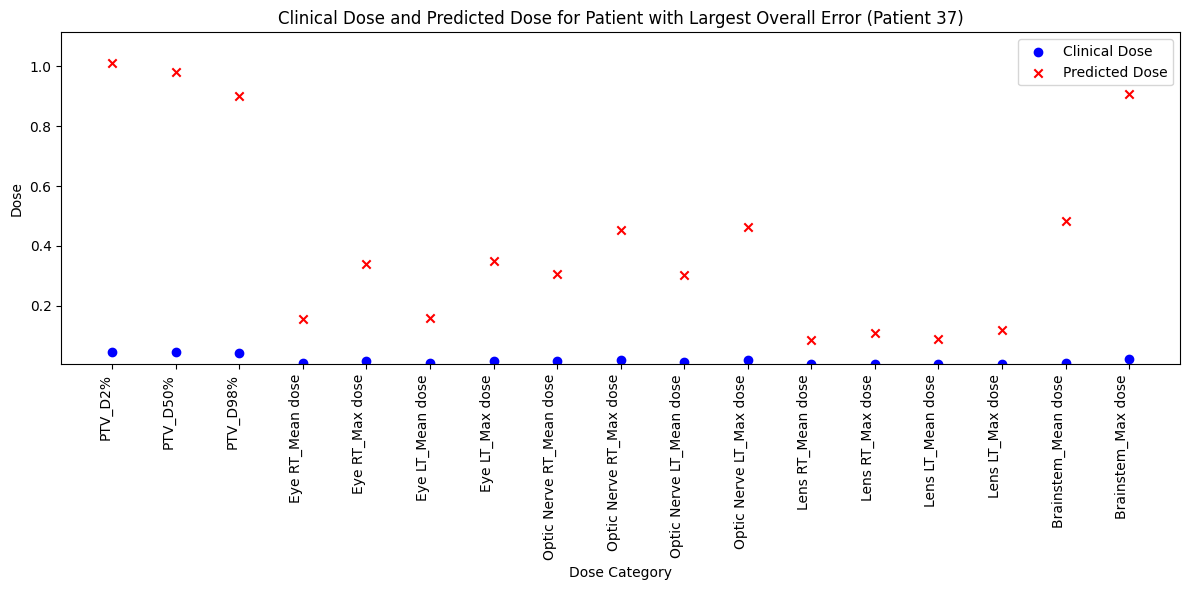

In [32]:
# Plotting the data for the patient with the largest overall error
plt.figure(figsize=(12, 6))
plt.scatter(range(len(columns_of_interest)), clinical_dose_max_error, marker='o', color='b', label='Clinical Dose')
plt.scatter(range(len(columns_of_interest)), predicted_dose_max_error, marker='x', color='r', label='Predicted Dose')
plt.xlabel('Dose Category')
plt.ylabel('Dose')
plt.title(f'Clinical Dose and Predicted Dose for Patient with Largest Overall Error (Patient {max_error_patient_index})')
plt.xticks(range(len(columns_of_interest)), columns_of_interest, rotation=90, ha='right')
plt.legend()
plt.ylim(min(min(clinical_dose_max_error), min(predicted_dose_max_error)) * 0.9, max(max(clinical_dose_max_error), max(predicted_dose_max_error)) * 1.1)  # Memperbesar skala sumbu y
plt.tight_layout()
plt.show()

In [33]:
# ================================================================
# UJI WILCOXON — HOMOGENEITY INDEX (HI) & CONFORMITY INDEX (CI)
# ================================================================
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

# Konversi ke numpy array (aman untuk list maupun array)
HI_true = np.array(hi_true)
HI_pred = np.array(hi_pred)
CI_true = np.array(ci_true)
CI_pred = np.array(ci_pred)

stat_hi, p_hi = wilcoxon(HI_true, HI_pred)
stat_ci, p_ci = wilcoxon(CI_true, CI_pred)

def sig_label(p):
    return 'Signifikan (p < 0.05)' if p < 0.05 else 'Tidak Signifikan (p >= 0.05)'

print('=' * 65)
print('WILCOXON SIGNED-RANK TEST — HI & CI  (Random Forest)')
print('=' * 65)
print(f'{"Index":<8} {"Statistic":>12} {"P-value":>14}  Hasil')
print('-' * 65)
print(f'{"HI":<8} {stat_hi:>12.4f} {p_hi:>14.6f}  {sig_label(p_hi)}')
print(f'{"CI":<8} {stat_ci:>12.4f} {p_ci:>14.6f}  {sig_label(p_ci)}')
print('=' * 65)

wilcoxon_hi_ci_df = pd.DataFrame([
    {'Index': 'HI', 'Statistic': stat_hi, 'P-value': p_hi, 'Significant': 'Yes' if p_hi < 0.05 else 'No'},
    {'Index': 'CI', 'Statistic': stat_ci, 'P-value': p_ci, 'Significant': 'Yes' if p_ci < 0.05 else 'No'},
])

wilcoxon_hi_ci_df.to_csv('wilcoxon_hi_ci_randomforest.csv', index=False)
print('\nSaved : wilcoxon_hi_ci_randomforest.csv')

WILCOXON SIGNED-RANK TEST — HI & CI  (Random Forest)
Index       Statistic        P-value  Hasil
-----------------------------------------------------------------
HI           417.0000       0.005069  Signifikan (p < 0.05)
CI           349.0000       0.000704  Signifikan (p < 0.05)

Saved : wilcoxon_hi_ci_randomforest.csv


In [34]:
# ================================================================
# UJI WILCOXON — 19 FITUR DOSIOMIK (TESTING SET)
# ================================================================
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

# Pastikan dalam bentuk numpy array
Y_testing_arr     = np.array(Y_testing)
Y_pred_testing_arr = np.array(Y_pred_testing)

print("\n" + "=" * 110)
print("WILCOXON SIGNED-RANK TEST RESULTS  (Random Forest — Testing Set)")
print("=" * 110)
print(f"{'No':<4} {'Feature':<40} {'Clinical (mean±SD)':<25} {'Predicted (mean±SD)':<25} {'Statistic':<12} {'P-value':<12} {'Significant'}")
print("=" * 110)

wilcoxon_results = []

for i in range(len(Y_label)):
    mean_clin = np.mean(Y_testing_arr[:, i])
    std_clin  = np.std(Y_testing_arr[:, i])
    mean_pred = np.mean(Y_pred_testing_arr[:, i])
    std_pred  = np.std(Y_pred_testing_arr[:, i])

    clinical_str  = f"{mean_clin:.3f}±{std_clin:.3f}"
    predicted_str = f"{mean_pred:.3f}±{std_pred:.3f}"

    try:
        stat, p_value = wilcoxon(Y_testing_arr[:, i], Y_pred_testing_arr[:, i])
    except ValueError:
        stat, p_value = 0.0, 1.0  # tidak ada perbedaan sama sekali

    is_significant = "Yes" if p_value < 0.05 else "No"

    wilcoxon_results.append({
        'Feature'              : Y_label[i],
        'Clinical (mean±SD)'   : clinical_str,
        'Predicted (mean±SD)'  : predicted_str,
        'Statistic'            : stat,
        'P-value'              : p_value,
        'Significant'          : is_significant
    })

    print(f"{i+1:<4} {Y_label[i]:<40} {clinical_str:<25} {predicted_str:<25} {stat:<12.2f} {p_value:<12.6f} {is_significant}")

wilcoxon_df = pd.DataFrame(wilcoxon_results)
wilcoxon_df.to_csv('wilcoxon_test_results_randomforest.csv', index=False)
print("\nFile 'wilcoxon_test_results_randomforest.csv' saved!")


WILCOXON SIGNED-RANK TEST RESULTS  (Random Forest — Testing Set)
No   Feature                                  Clinical (mean±SD)        Predicted (mean±SD)       Statistic    P-value      Significant
1    PTV_D2% (GY)                             0.961±0.257               0.979±0.057               436.00       0.008314     Yes
2    PTV_D50% (GY)                            0.921±0.239               0.936±0.053               375.00       0.001555     Yes
3    PTV_D98% (GY)                            0.851±0.254               0.855±0.062               372.00       0.001422     Yes
4    PTV_V95 (cc)                             0.940±0.129               0.950±0.006               349.00       0.000704     Yes
5    PTV_Volume (cc)                          1.000±0.000               1.000±0.000               0.00         nan          No
6    Eye RT_Mean dose (GY)                    0.141±0.092               0.149±0.033               616.00       0.276069     No
7    Eye RT_Max dose (GY)       

C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [35]:
# ================================================================
# RINGKASAN HASIL UJI WILCOXON
# ================================================================
n_sig   = wilcoxon_df['Significant'].value_counts().get('Yes', 0)
n_total = len(wilcoxon_df)

print('=' * 60)
print('WILCOXON TEST SUMMARY  (Random Forest)')
print('=' * 60)
print(f'Total fitur diuji            : {n_total}')
print(f'Signifikan (p < 0.05)        : {n_sig}  ({n_sig/n_total*100:.1f}%)')
print(f'Tidak signifikan (p >= 0.05) : {n_total - n_sig}  ({(n_total-n_sig)/n_total*100:.1f}%)')
print('-' * 60)
print(f'{"No":<4} {"Feature":<40} {"P-value":>12}  Keterangan')
print('-' * 60)
for _, row in wilcoxon_df.iterrows():
    ket = "Signifikan *" if row['Significant'] == 'Yes' else "Tidak Signifikan"
    print(f'{_+1:<4} {row["Feature"]:<40} {row["P-value"]:>12.6f}  {ket}')
print('=' * 60)

# Wilcoxon HI & CI summary
print()
print('=' * 60)
print('WILCOXON — HI & CI SUMMARY')
print('=' * 60)
for _, row in wilcoxon_hi_ci_df.iterrows():
    ket = "Signifikan *" if row['Significant'] == 'Yes' else "Tidak Signifikan"
    print(f'  {row["Index"]:<6} p = {row["P-value"]:.6f}  →  {ket}')
print('=' * 60)

WILCOXON TEST SUMMARY  (Random Forest)
Total fitur diuji            : 19
Signifikan (p < 0.05)        : 4  (21.1%)
Tidak signifikan (p >= 0.05) : 15  (78.9%)
------------------------------------------------------------
No   Feature                                       P-value  Keterangan
------------------------------------------------------------
1    PTV_D2% (GY)                                 0.008314  Signifikan *
2    PTV_D50% (GY)                                0.001555  Signifikan *
3    PTV_D98% (GY)                                0.001422  Signifikan *
4    PTV_V95 (cc)                                 0.000704  Signifikan *
5    PTV_Volume (cc)                                   nan  Tidak Signifikan
6    Eye RT_Mean dose (GY)                        0.276069  Tidak Signifikan
7    Eye RT_Max dose (GY)                         0.164362  Tidak Signifikan
8    Eye LT_Mean dose (GY)                        0.907464  Tidak Signifikan
9    Eye LT_Max dose (GY)                        

In [36]:
from scipy.stats import wilcoxon

TARGET_PTV = [
    'PTV_D2% (GY)', 'PTV_D50% (GY)', 'PTV_D98% (GY)',
    'PTV_V95 (cc)', 'PTV_Volume (cc)',
]
TARGET_OAR = [
    'Brainstem_Mean dose (GY)', 'Brainstem_Max dose (GY)',
    'Eye RT_Mean dose (GY)', 'Eye RT_Max dose (GY)',
    'Eye LT_Mean dose (GY)', 'Eye LT_Max dose (GY)',
    'Optic Nerve RT_Mean dose (GY)', 'Optic Nerve RT_Max dose (GY)',
    'Optic Nerve LT_Mean dose (GY)', 'Optic Nerve LT_Max dose (GY)',
    'Lens RT_Mean dose (GY)', 'Lens RT_Max dose (GY)',
    'Lens LT_Mean dose (GY)', 'Lens LT_Max dose (GY)',
]
TARGET_19 = TARGET_PTV + TARGET_OAR
idx_19 = [Y_label.index(t) for t in TARGET_19]

n_significant = 0
n_total = len(TARGET_19)

print("="*80)
print("WILCOXON SIGNED-RANK TEST — 19 TARGET (TESTING SET)")
print("="*80)

for t_name, t_idx in zip(TARGET_19, idx_19):
    actual = Y_testing[:, t_idx]
    pred = Y_pred_testing[:, t_idx]
    diff = actual - pred
    if np.all(diff == 0):
        p_val = 1.0
    else:
        try:
            _, p_val = wilcoxon(actual, pred)
        except:
            p_val = 1.0
    sig = "Yes" if p_val < 0.05 else "No"
    if sig == "Yes":
        n_significant += 1
    print(f"  {t_name:<38} p={p_val:.6f}  Significant: {sig}")

print("\n" + "="*80)
print("WILCOXON TEST SUMMARY (19 TARGET):")
print("="*80)
print(f"Total features tested: {n_total}")
print(f"Significantly different (p < 0.05): {n_significant}")
print(f"Not significantly different (p >= 0.05): {n_total - n_significant}")
print(f"Percentage significantly different: {(n_significant/n_total)*100:.2f}%")


WILCOXON SIGNED-RANK TEST — 19 TARGET (TESTING SET)
  PTV_D2% (GY)                           p=0.008314  Significant: Yes
  PTV_D50% (GY)                          p=0.001555  Significant: Yes
  PTV_D98% (GY)                          p=0.001422  Significant: Yes
  PTV_V95 (cc)                           p=0.000704  Significant: Yes
  PTV_Volume (cc)                        p=1.000000  Significant: No
  Brainstem_Mean dose (GY)               p=0.955369  Significant: No
  Brainstem_Max dose (GY)                p=0.521223  Significant: No
  Eye RT_Mean dose (GY)                  p=0.276069  Significant: No
  Eye RT_Max dose (GY)                   p=0.164362  Significant: No
  Eye LT_Mean dose (GY)                  p=0.907464  Significant: No
  Eye LT_Max dose (GY)                   p=0.590481  Significant: No
  Optic Nerve RT_Mean dose (GY)          p=0.510100  Significant: No
  Optic Nerve RT_Max dose (GY)           p=0.812827  Significant: No
  Optic Nerve LT_Mean dose (GY)          p=0.37